Import các thư viện cần thiết như Numpy và Pandas

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(np.__version__)
print(pd.__version__)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # set up width 


2.4.3
3.0.1


Đọc datasets

In [150]:
df = pd.read_csv("../data/diabetes.csv")
print(df.shape) # Kích thước có 768 bệnh nhân và 9 cột bệnh lý
print('==================================================')
print(df.info()) #Thông tin kiểu dữ liệu của datasets
print('==================================================')


(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Kiểm tra giá trị bất thường

In [151]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_values = (df[cols] == 0).sum()

zero_table = pd.DataFrame({
    "Feature": zero_values.index,
    "Zero Values": zero_values.values,
    "Percentage %": (zero_values / len(df) * 100).round(3)
})

print("Các giá trị 0 bất thường")
display(zero_table)

df[cols] = df[cols].replace(0, np.nan)

Các giá trị 0 bất thường


,Feature,Zero Values,Percentage %
Glucose,Glucose,5,0.651
BloodPressure,BloodPressure,35,4.557
SkinThickness,SkinThickness,227,29.557
Insulin,Insulin,374,48.698
BMI,BMI,11,1.432


Thống kê dữ liệu

In [152]:
eda_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(3).values,
    "Mean": df.mean().round(3).values,
    "Std": df.std().round(3).values,
    "Min": df.min().values,
    "Max": df.max().values
})
print("Bảng thống kê dữ liệu")
display(eda_summary.sort_values('Missing %',ascending=False).reset_index(drop=True))

Bảng thống kê dữ liệu


,Feature,Missing Values,Missing %,Mean,Std,Min,Max
0,Insulin,374,48.698,155.548,118.776,14.000,846.00
1,SkinThickness,227,29.557,29.153,10.477,7.000,99.00
2,BloodPressure,35,4.557,72.405,12.382,24.000,122.00
3,BMI,11,1.432,32.457,6.925,18.200,67.10
4,Glucose,5,0.651,121.687,30.536,44.000,199.00
5,Pregnancies,0,0.000,3.845,3.370,0.000,17.00
6,DiabetesPedigreeFunction,0,0.000,0.472,0.331,0.078,2.42
7,Age,0,0.000,33.241,11.760,21.000,81.00
8,Outcome,0,0.000,0.349,0.477,0.000,1.00


Sau khi kiểm tra dữ liệu, phát hiện ra một số cột chứa giá trị 0 không hợp lý. 
Các giá trị này được coi là missing values và được chuyển thành NaN.

Cột Insulin có tỷ lệ thiếu cao nhất (~48,698%), tiếp theo là cột SkinThickness (~29,557%).
Các cột còn lại có tỷ lệ thiếu thấp (<5%).

BIỂU ĐỒ BIẾN MỤC TIÊU

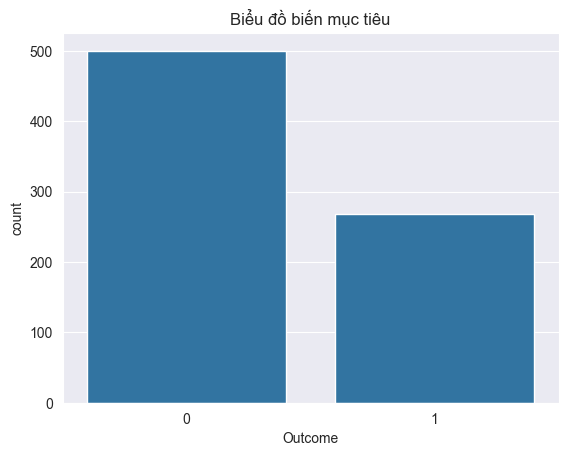

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.title('Biểu đồ biến mục tiêu')

plt.show()

In [154]:

df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [155]:
df['Outcome'].value_counts(normalize = True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

=> Biểu đồ cho thấy số lượng người không mắc tiểu đường( Outcome = 0) nhiều hơn người bị mắc tiểu đường (Outcome = 1). 
Dữ liệu bị mất cân bằng giữa hai lớp.

**Distribution Plots (Histogram, KDE cho numerical features)**

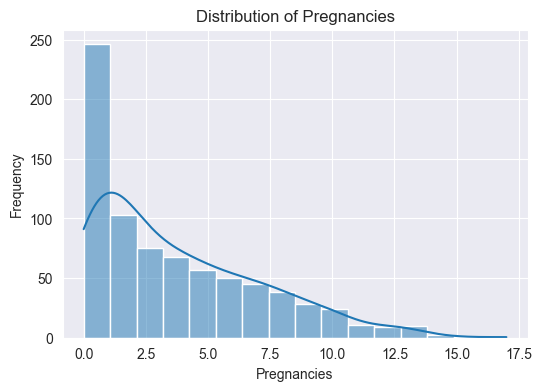

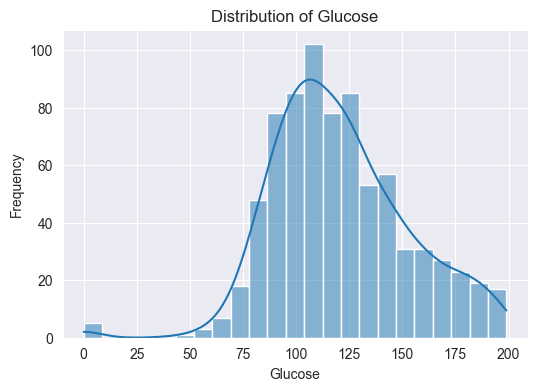

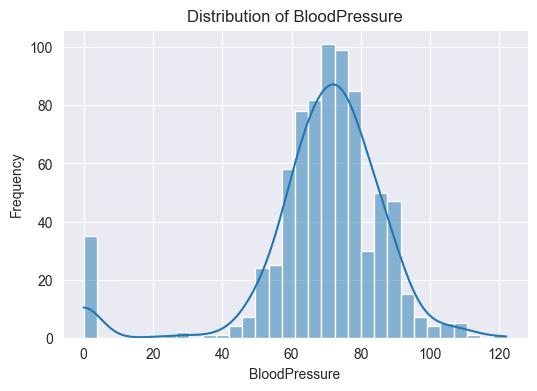

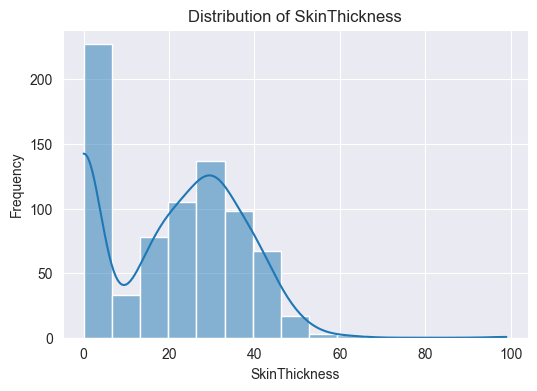

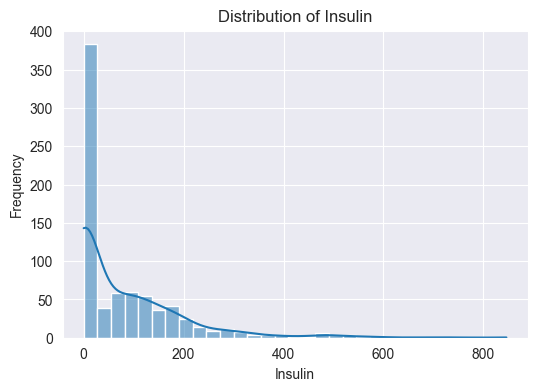

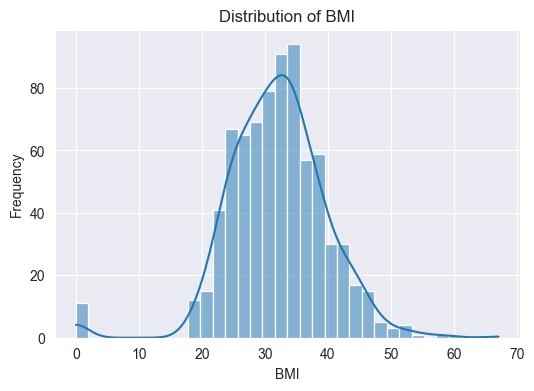

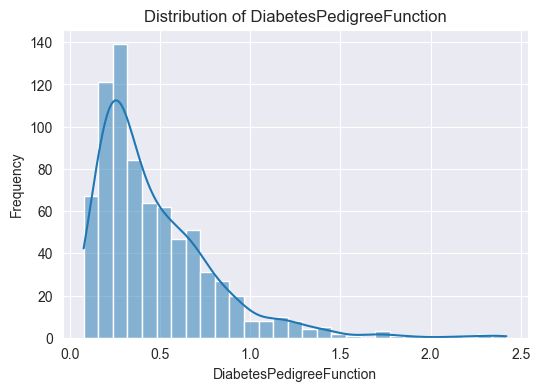

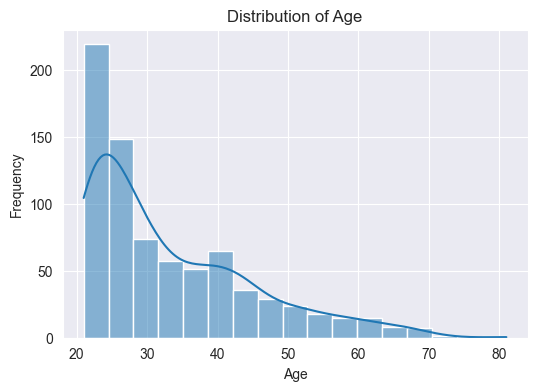

In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetes.csv")

numerical_features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

CORRELATION HEATMAP

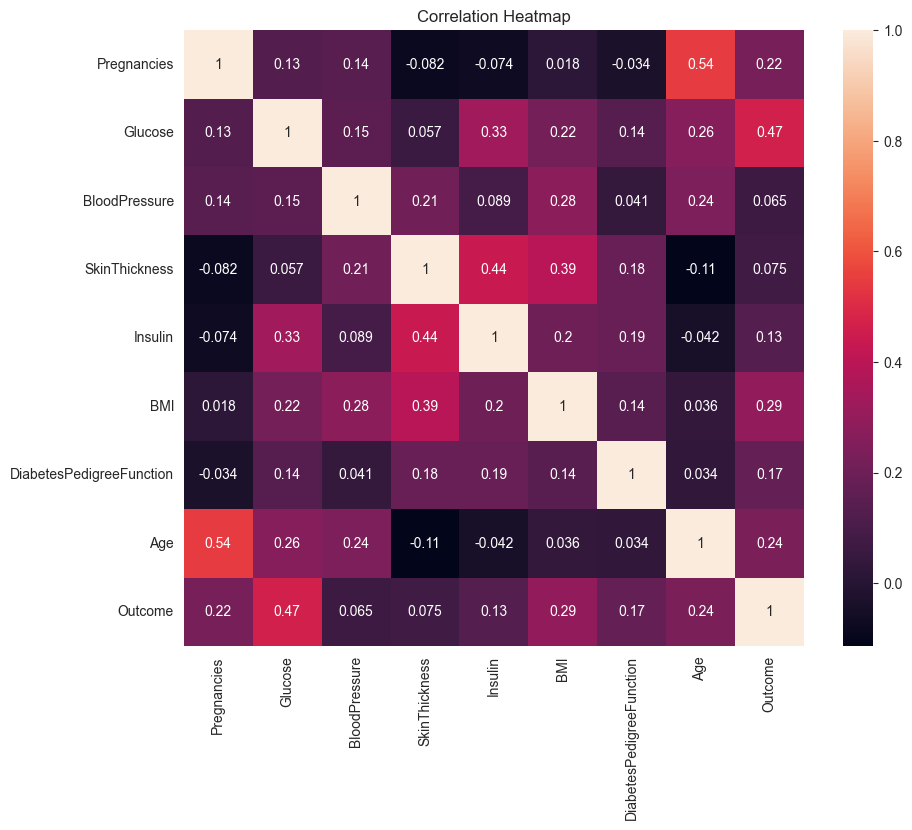

In [157]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
cmap="coolwwarm"
plt.title('Correlation Heatmap')
plt.show()

=> Biểu đồ correlation heatmap cho thấy mối tương quan giữa các biến trong dataset.
+ "Glucose" có hệ số tương quan cao nhất với "Outcome" là 0.49 -> lượng đường cao dẫn đến khả năng mắc bệnh tiểu đường.

**Categorical Analysis**

**Bar plots**

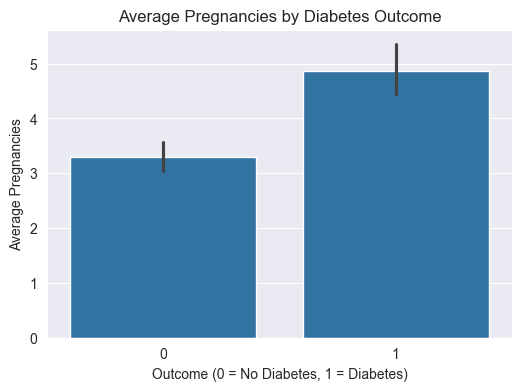

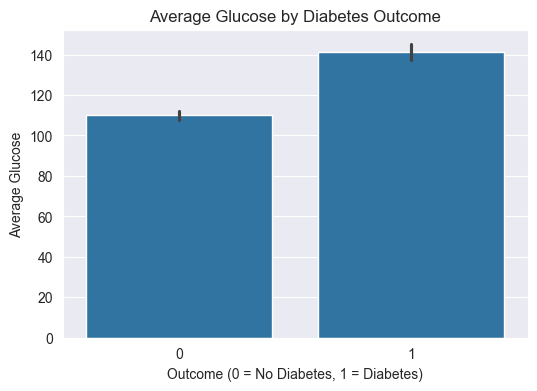

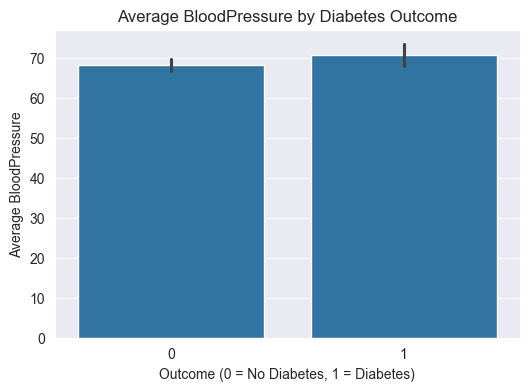

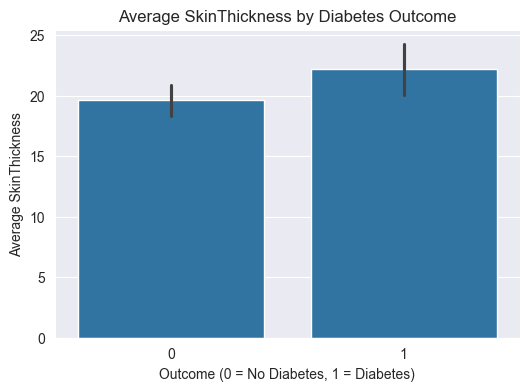

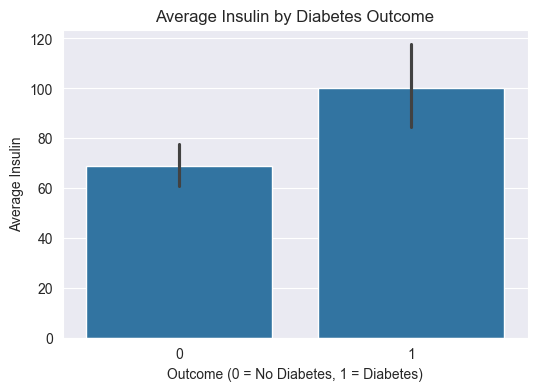

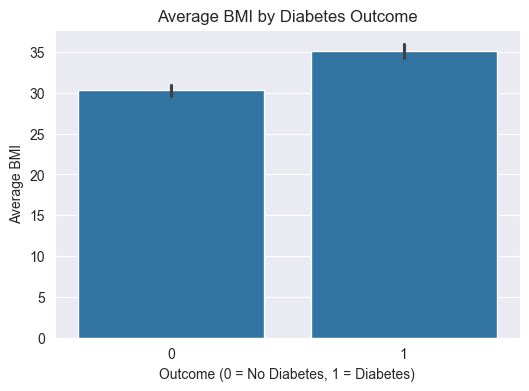

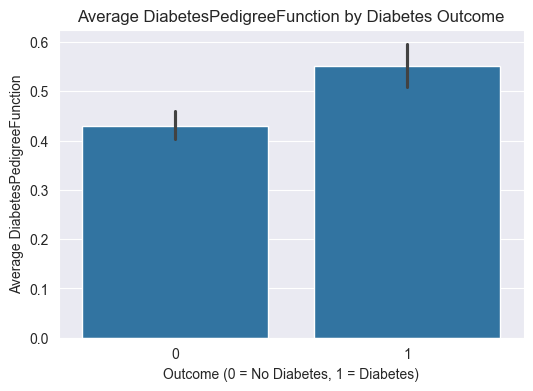

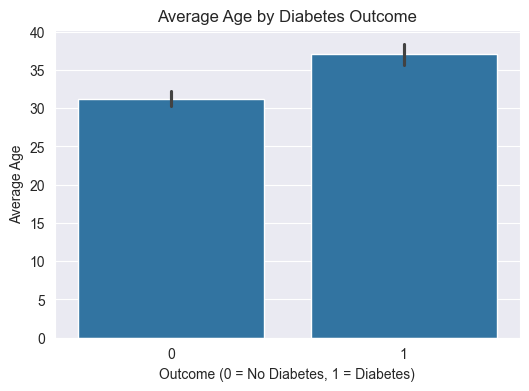

In [158]:
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Outcome', y=col, data=df)

    plt.title(f'Average {col} by Diabetes Outcome')
    plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
    plt.ylabel(f'Average {col}')

    plt.show()

**Count plots**

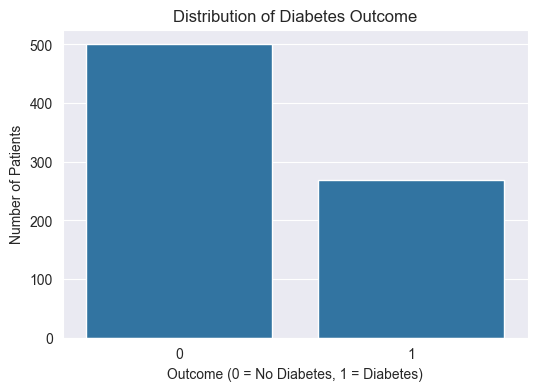

In [159]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

PHÂN TÍCH BOXPLOT (PHÁT HIỆN OUTLIERS)

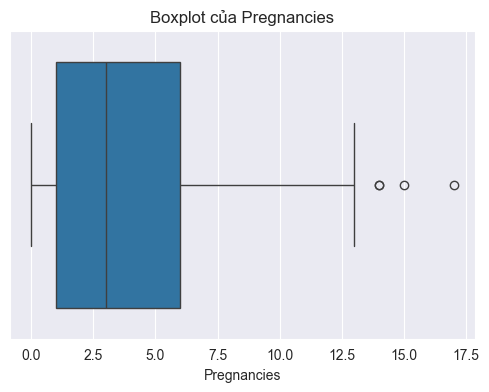

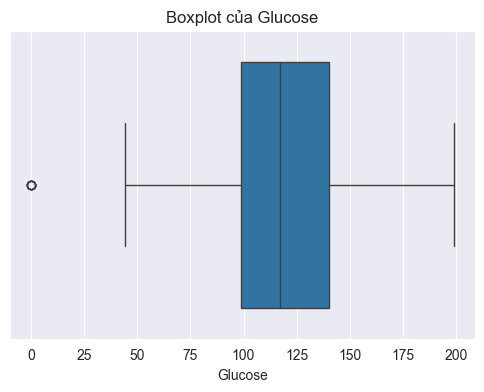

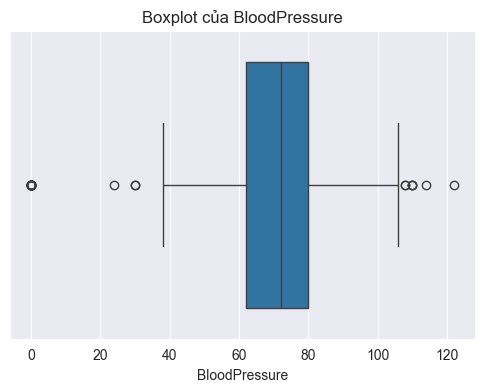

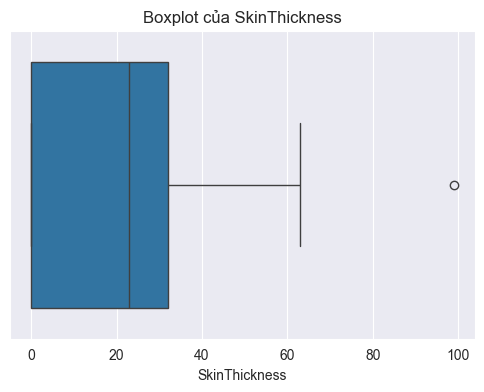

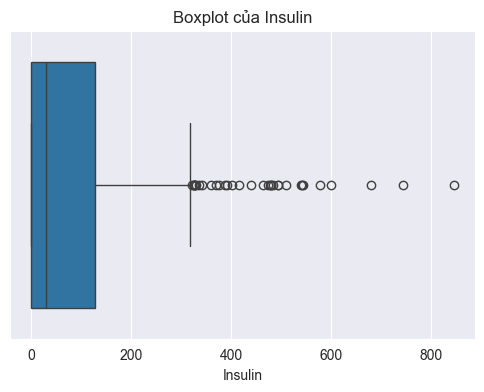

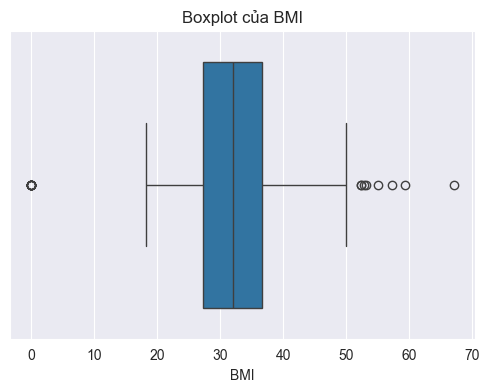

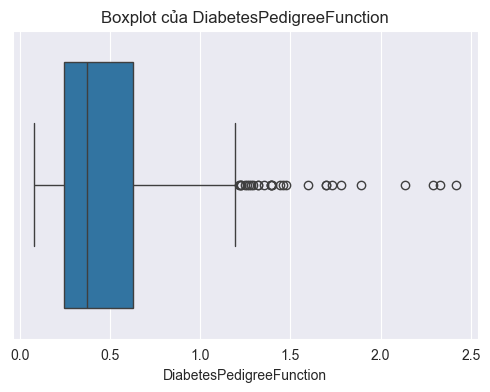

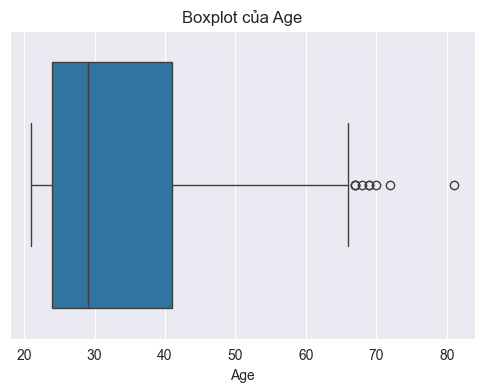

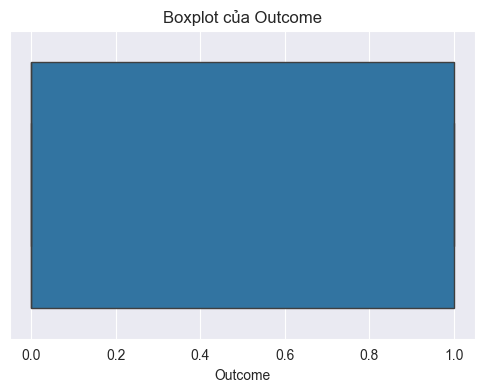

In [160]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot của {col}')
    
    plt.show()

PHÂN TÍCH OUTLIERS BẰNG PHƯƠNG PHÁP IQR

In [161]:
outlier_results = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_results)

print('Bảng kết quả phát hiện outliers:')
print(outlier_df)


Bảng kết quả phát hiện outliers:
                    Feature        Q1         Q3       IQR  Lower Bound  Upper Bound  Number of Outliers
0               Pregnancies   1.00000    6.00000    5.0000       -6.500       13.500                   4
1                   Glucose  99.00000  140.25000   41.2500       37.125      202.125                   5
2             BloodPressure  62.00000   80.00000   18.0000       35.000      107.000                  45
3             SkinThickness   0.00000   32.00000   32.0000      -48.000       80.000                   1
4                   Insulin   0.00000  127.25000  127.2500     -190.875      318.125                  34
5                       BMI  27.30000   36.60000    9.3000       13.350       50.550                  19
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825       -0.330        1.200                  29
7                       Age  24.00000   41.00000   17.0000       -1.500       66.500                   9
8                   Ou

KIỂM ĐỊNH THỐNG KÊ T-TEST

In [162]:
from scipy.stats import ttest_ind
ttest_results = []

for col in numeric_cols:
    
    if col != 'Outcome':
        
        group0 = df[df['Outcome'] == 0][col]
        group1 = df[df['Outcome'] == 1][col]
        
        t_stat, p_value = ttest_ind(group0, group1)
        
        ttest_results.append({
            'Feature': col,
            'T-statistic': t_stat,
            'P-value': p_value
        })

ttest_df = pd.DataFrame(ttest_results)

print('Kết quả kiểm định t-test:')
print(ttest_df)

Kết quả kiểm định t-test:
                    Feature  T-statistic       P-value
0               Pregnancies    -6.298431  5.065127e-10
1                   Glucose   -14.600060  8.935432e-43
2             BloodPressure    -1.804702  7.151390e-02
3             SkinThickness    -2.074700  3.834770e-02
4                   Insulin    -3.644325  2.861865e-04
5                       BMI    -8.471840  1.229807e-16
6  DiabetesPedigreeFunction    -4.885826  1.254607e-06
7                       Age    -6.792688  2.209975e-11


NHẬN XÉT KẾT QUẢ KIỂM ĐỊNH

In [163]:
for i,row in ttest_df.iterrows():
    
    if row['P-value'] < 0.05:
        print(f"{row['Feature']} -> Có sự khác biệt, có ý nghĩa thống kê (p = {row['P-value']:.5f})")
    else:
        print(f"{row['Feature']} -> Không có sự khác biệt đáng kể (p = {row['P-value']:.5f})")

Pregnancies -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
Glucose -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
BloodPressure -> Không có sự khác biệt đáng kể (p = 0.07151)
SkinThickness -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.03835)
Insulin -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00029)
BMI -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
DiabetesPedigreeFunction -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
Age -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)


 KIỂM ĐỊNH CHI-SQUARE 

In [164]:
from scipy.stats import chi2_contingency


df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60,100],
    labels=['20-30','30-40','40-50','50-60','60+']
)

contingency_table = pd.crosstab(df['Age_Group'], df['Outcome'])

print('Bảng chéo Age_Group và Outcome:')
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print('Kết quả kiểm định Chi-Square:')
print('Chi-square statistic:', chi2)
print('P-value:', p)
print('Degrees of freedom:', dof)

print('Bảng giá trị kỳ vọng:')
print(expected)



Bảng chéo Age_Group và Outcome:
Outcome      0   1
Age_Group         
20-30      327  90
30-40       81  76
40-50       49  64
50-60       23  31
60+         20   7
Kết quả kiểm định Chi-Square:
Chi-square statistic: 81.6612857019655
P-value: 7.74411254791731e-17
Degrees of freedom: 4
Bảng giá trị kỳ vọng:
[[271.484375   145.515625  ]
 [102.21354167  54.78645833]
 [ 73.56770833  39.43229167]
 [ 35.15625     18.84375   ]
 [ 17.578125     9.421875  ]]


NHẬN XÉT CHI-SQUARE 

In [165]:
if p < 0.05:
    print('Có mối quan hệ có ý nghĩa thống kê giữa Age_Group và Outcome')
else:
    print('Không có bằng chứng về mối quan hệ giữa Age_Group và Outcome')

Có mối quan hệ có ý nghĩa thống kê giữa Age_Group và Outcome


In [166]:
# Sau khi print kết quả Chi-Square xong:
df.drop(columns=['Age_Group'], inplace=True, errors='ignore')

In [167]:
# Xử lý giá trị trống bằng giá trị trung vị
df.fillna(df.median(numeric_only=True), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [168]:
# kiểm tra giá trị trống sau khi xử lý
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [169]:
# KHÔNG CẦN ENCODING vì tất cả dữ liệu trong bảng đã là dạng số.

TRỰC QUAN HÓA DỮ LIỆU

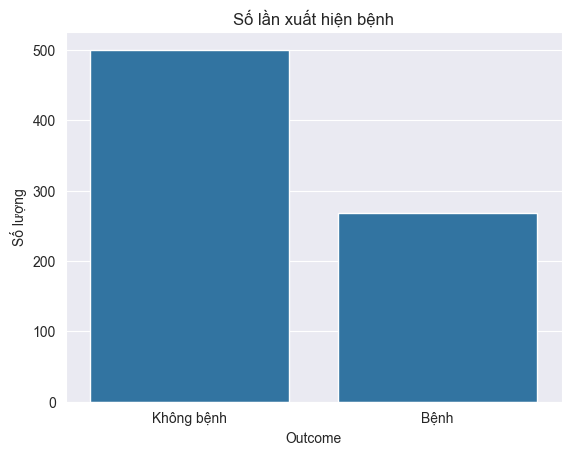

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title('Số lần xuất hiện bệnh')
plt.xticks([0,1], ["Không bệnh","Bệnh"])
plt.show()

In [171]:
# Số lượng class
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

=> Biểu đồ cho thấy Dữ liệu bị mất cân bằng

CÂN BẰNG DỮ LIỆU (SMOTE)

In [172]:
# Tách X và Y
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [173]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [174]:
#  CÂN BẰNG
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=43)
X_resampled, Y_resampled = smote.fit_resample(X, df['Outcome'])

Outcome_count2 = Y_resampled.value_counts()

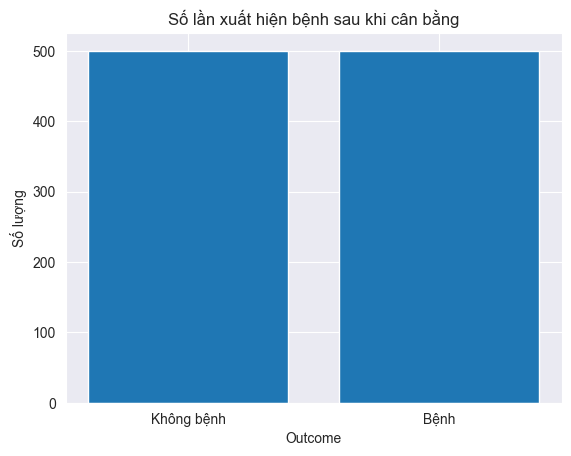

In [175]:
counts = Y_resampled.value_counts()

plt.bar(counts.index, counts.values)

plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title("Số lần xuất hiện bệnh sau khi cân bằng")

plt.xticks([0,1], ["Không bệnh","Bệnh"])

plt.show()

In [176]:
# đếm số lượng của các loại bệnh sau cân bằng
Y_resampled.value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

TRAIN/TEST

In [177]:
# chia dữ liệu thành train và test 8:2
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, stratify=Y_resampled,random_state=0)

In [178]:
# (dòng, cột) của tập dữ liệu trước và sau khi chia train test
print(X_resampled.shape, X_train.shape, X_test.shape)

(1000, 8) (800, 8) (200, 8)


SCALING (STANDARDSCALER): giúp đưa dữ liệu về dạng có trung bình (mean) xấp xỉ bằng 0 và độ lệch chuẩn (std) bằng 1 
z = ( x - μ ) / σ

μ : mean
σ : standard deviation

In [179]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train, columns = X.columns)
print(X_train_df)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  DiabetesPedigreeFunction       Age
0       0.268015 -0.537124       0.559916       0.995125  0.894357  0.151887                 -0.102540 -0.158832
1      -0.604762 -0.629071      -0.355166      -0.427697 -0.172263 -0.982325                  0.713740 -0.867708
2       1.431719 -0.199985       0.509078       0.871402 -0.683894 -0.517691                 -0.724901 -0.424661
3       0.558941  1.117923      -0.406004      -1.293763 -0.683894 -1.150431                 -0.987845  1.436138
4      -1.186614 -0.659720      -0.304328       0.995125 -0.128905  0.101587                  0.039182 -1.044927
..           ...       ...            ...            ...       ...       ...                       ...       ...
795    -0.022910  0.382347       1.576673      -1.293763 -0.683894  1.965729                 -0.471745 -0.158832
796    -0.895688  0.412996       0.000699      -1.293763 -0.683894  0.040055                 -0.

FEATURE ENGINEERING

In [180]:
df = pd.read_csv("../data/diabetes.csv")#Reset lại dữ liệu gốc,Tránh lỗi mất cột do chạy notebook nhiều lần
print("=== Original Columns ===")
print(df.columns.tolist())

=== Original Columns ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [181]:
# Feature 1: BMI Category
df["BMI_Category"] = pd.cut(df["BMI"],
                           bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=["Underweight", "Normal", "Overweight", "Obese"])

Giải thích tại sao lại tạo Feature BMI Category
1.BMI là biến liên tục, nhưng trong thực tế y khoa, BMI thường được phân loại thành các nhóm như:
    Gầy (Underweight)
    Bình thường (Normal)
    Thừa cân (Overweight)
    Béo phì (Obese)
2.Việc chuyển BMI thành dạng phân loại giúp mô hình:
    Dễ nhận diện các mức độ rủi ro sức khỏe
    Nắm bắt được các ngưỡng quan trọng (threshold) thay vì chỉ giá trị số
3.Ý nghĩa
    Các nghiên cứu cho thấy người thừa cân và béo phì có nguy cơ mắc bệnh tiểu đường cao hơn, do đó feature này giúp mô hình học tốt hơn về nguy cơ bệnh.

In [182]:
# Feature 2: Glucose/BMI Ratio
df["Glucose_BMI_Ratio"] = df["Glucose"] / (df["BMI"] + 1e-5)

Giải thích tại sao lại tạo Feature Glucose/BMI Ratio 1.Glucose và BMI là hai yếu tố quan trọng ảnh hưởng đến bệnh tiểu đường. Tuy nhiên, khi xét riêng lẻ, mỗi biến chỉ phản ánh một khía cạnh. 2.Việc tạo tỷ lệ giữa Glucose và BMI giúp: Kết hợp thông tin của hai biến thành một đặc trưng mới Phản ánh mối quan hệ tương đối giữa đường huyết và thể trạng 3.Ý nghĩa Một người có glucose cao nhưng BMI thấp có thể có nguy cơ khác so với người có cùng glucose nhưng BMI cao. Feature này giúp mô hình phân biệt các trường hợp đó tốt hơn.

In [183]:
# Feature 3: Age Group
df["Age_Group"] = pd.cut(df["Age"],
                        bins=[0, 30, 50, 100],
                        labels=["Young", "Middle", "Old"])

Giải thích tại sao lại tạo Feature Age Group
1.Tuổi là biến liên tục, nhưng nguy cơ mắc bệnh thường tăng theo từng giai đoạn tuổi chứ không tăng đều.
2.Việc chia nhóm tuổi giúp:
    Đơn giản hóa dữ liệu
    Làm nổi bật các nhóm có nguy cơ khác nhau
3.Ý nghĩa 
    Người lớn tuổi thường có nguy cơ mắc tiểu đường cao hơn so với người trẻ. Feature này giúp mô hình học được xu hướng theo nhóm tuổi rõ ràng hơn.

PREVIEW FEATURES

In [184]:
print("\n=== Preview Features ===")
print(df[["BMI_Category", "Glucose_BMI_Ratio", "Age_Group"]].head(10))

print("\n=== BMI_Category Distribution ===")
print(df["BMI_Category"].value_counts())

print("\n=== Age_Group Distribution ===")
print(df["Age_Group"].value_counts())

print("\n=== Glucose_BMI_Ratio Stats ===")
print(df["Glucose_BMI_Ratio"].describe())


=== Preview Features ===
  BMI_Category  Glucose_BMI_Ratio Age_Group
0        Obese       4.404761e+00    Middle
1   Overweight       3.195488e+00    Middle
2       Normal       7.854074e+00    Middle
3   Overweight       3.167259e+00     Young
4        Obese       3.178654e+00    Middle
5   Overweight       4.531248e+00     Young
6        Obese       2.516128e+00     Young
7        Obese       3.257789e+00     Young
8        Obese       6.459014e+00       Old
9          NaN       1.250000e+07       Old

=== BMI_Category Distribution ===
BMI_Category
Obese          472
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64

=== Age_Group Distribution ===
Age_Group
Young     417
Middle    270
Old        81
Name: count, dtype: int64

=== Glucose_BMI_Ratio Stats ===
count    7.680000e+02
mean     1.493528e+05
std      1.259901e+06
min      0.000000e+00
25%      3.053626e+00
50%      3.768472e+00
75%      4.623584e+00
max      1.360000e+07
Name: Glucose_BMI_Rat

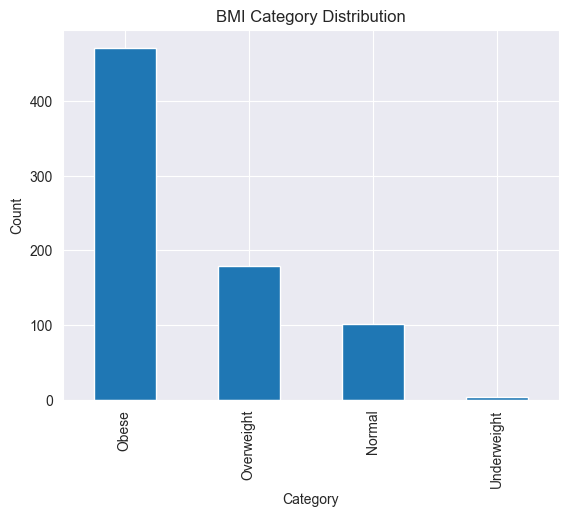

In [185]:
df["BMI_Category"].value_counts().plot(kind="bar")
plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

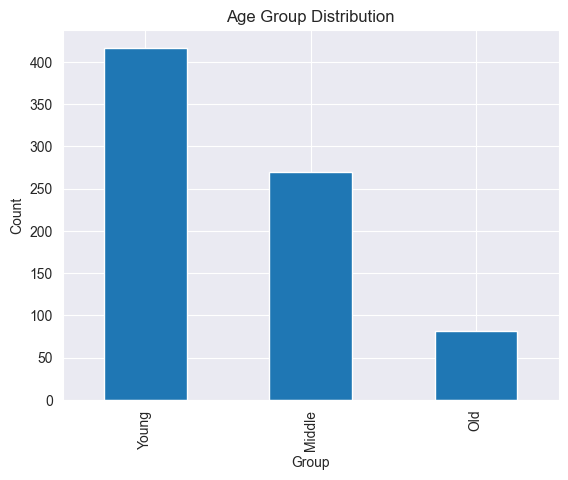

In [186]:
df["Age_Group"].value_counts().plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

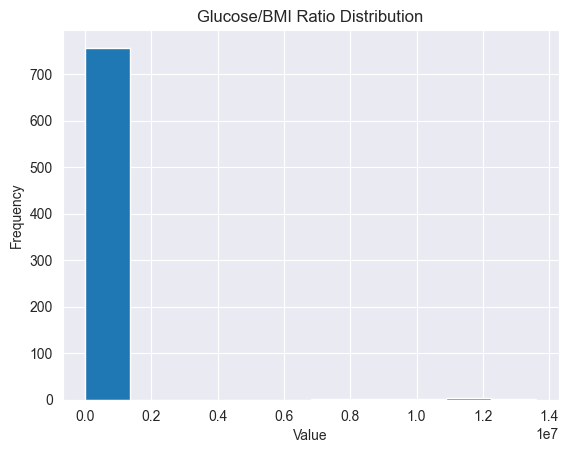

In [187]:
df["Glucose_BMI_Ratio"].hist()
plt.title("Glucose/BMI Ratio Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Encoding

In [188]:
df = pd.get_dummies(df, columns=["BMI_Category", "Age_Group"], drop_first=True)

print("\n=== Columns AFTER Encoding ===")
print(df.columns.tolist())


=== Columns AFTER Encoding ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI_Ratio', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Age_Group_Middle', 'Age_Group_Old']


In [189]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# BEFORE (không dùng feature mới)
X_old = df.drop(["Outcome", "Glucose_BMI_Ratio"], axis=1)
y = df["Outcome"]

model = RandomForestClassifier(random_state=42)
score_old = cross_val_score(model, X_old, y, cv=5).mean()

# AFTER (có feature mới)
X_new = df.drop("Outcome", axis=1)
score_new = cross_val_score(model, X_new, y, cv=5).mean()

print("\n=== MODEL EVALUATION ===")
print("Accuracy BEFORE:", score_old)
print("Accuracy AFTER:", score_new)


=== MODEL EVALUATION ===
Accuracy BEFORE: 0.7669807316866141
Accuracy AFTER: 0.7747729394788219


FEATURE IMPORTANCE


=== TOP 10 IMPORTANT FEATURES ===
Glucose                     0.199512
BMI                         0.123113
Glucose_BMI_Ratio           0.120268
Age                         0.101418
DiabetesPedigreeFunction    0.099929
BloodPressure               0.078241
Pregnancies                 0.072360
Insulin                     0.060777
SkinThickness               0.056592
BMI_Category_Obese          0.038798
dtype: float64


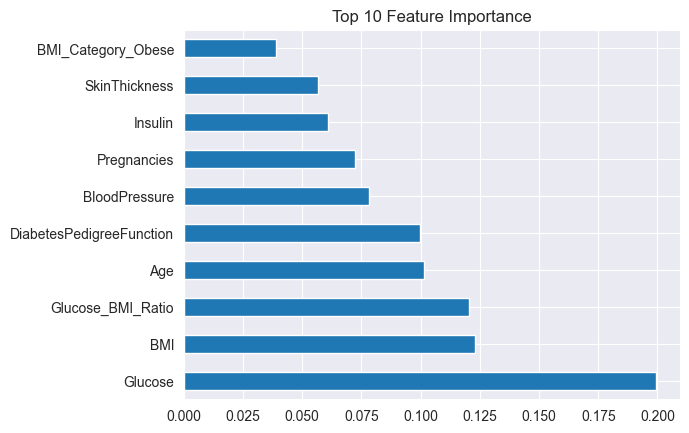

In [190]:
model.fit(X_new, y)

importances = pd.Series(model.feature_importances_, index=X_new.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("\n=== TOP 10 IMPORTANT FEATURES ===")
print(top_features)

top_features.plot(kind="barh")
plt.title("Top 10 Feature Importance")
plt.show()

**1.4. Modeling**

In [193]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# 1. Khai báo các Pipeline và bộ tham số (Hyperparameters) cho 3 mô hình
# Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()), # Preprocessing
    ('lr', LogisticRegression())  # model
])
param_lr = {'lr__C': [0.01, 0.1, 1, 10]}

# Random Forest
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))])
param_rf = {'rf__n_estimators': [50, 100, 200], 'rf__max_depth': [None, 5, 10]}

# SVM
# probability=True để dùng soft voting
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))])
param_svm = {'svm__C': [0.1, 1, 10], 'svm__kernel': ['linear', 'rbf']}

models = [
    ('Logistic Regression', pipe_lr, param_lr),
    ('Random Forest', pipe_rf, param_rf),
    ('SVM', pipe_svm, param_svm)
]

# Biến lưu trữ kết quả và mô hình tốt nhất để so sánh
evaluation_results = []
best_trained_models = {}

# 2. Train và đánh giá từng mô hình

for name, pipe, params in models:
    print(f"Đánh giá mô hình {name.upper()}")

    # Sử dụng GridSearchCV với 5-fold CV
    grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, Y_train)

    # Lấy mô hình tốt nhất sau khi tuning
    best_model = grid.best_estimator_
    best_trained_models[name] = best_model

    # Dự đoán trên tập Test
    y_pred = best_model.predict(X_test)
    test_acc = accuracy_score(Y_test, y_pred)

    print(f"- Bộ tham số tốt nhất: {grid.best_params_}")
    print(f"- Điểm Cross-Validation (Train): {grid.best_score_ * 100:.2f}%")
    print(f"- Độ chính xác (Test Accuracy): {test_acc * 100:.2f}%")
    print("- Báo cáo phân loại (Classification Report):")
    print(classification_report(Y_test, y_pred))
    print("="*60 + "\n")

    # Lưu lại thông tin để làm bảng so sánh
    evaluation_results.append({
        'Model': name,
        'CV Score (Train)': grid.best_score_,
        'Test Accuracy': test_acc
    })

# 3. Kết hợp các mô hình: VOTING CLASSIFIER

print("Đánh giá mô hình kết hợp (Voting Classifier)")

estimators_list = [
    ('lr', best_trained_models['Logistic Regression']),
    ('rf', best_trained_models['Random Forest']),
    ('svm', best_trained_models['SVM'])
]

voting_clf = VotingClassifier(estimators=estimators_list, voting='soft')

# Chạy Cross-validation để lấy điểm CV
cv_scores_voting = cross_val_score(voting_clf, X_train, Y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Fit mô hình và dự đoán trên tập test
voting_clf.fit(X_train, Y_train)
y_pred_voting = voting_clf.predict(X_test)
test_acc_voting = accuracy_score(Y_test, y_pred_voting)

# In kết quả đánh giá cho Voting Classifier
print(f"- Bộ tham số tốt nhất: Kết hợp từ 3 mô hình trên (Soft Voting)")
print(f"- Điểm Cross-Validation (Train): {cv_scores_voting.mean() * 100:.2f}%")
print(f"- Độ chính xác (Test Accuracy): {test_acc_voting * 100:.2f}%")
print("- Báo cáo phân loại (Classification Report):")
print(classification_report(Y_test, y_pred_voting))
print("="*60 + "\n")

# Lưu lại thông tin để làm bảng so sánh
evaluation_results.append({
    'Model': 'Voting Classifier',
    'CV Score (Train)': cv_scores_voting.mean(),
    'Test Accuracy': test_acc_voting
})
# Lưu lại mô hình vào dictionary
best_trained_models['Voting Classifier'] = voting_clf

# 4. BẢNG SO SÁNH KẾT QUẢ

print("=== BẢNG TỔNG HỢP SO SÁNH CÁC MÔ HÌNH ===")
df_results = pd.DataFrame(evaluation_results)
# Sắp xếp theo Test Accuracy giảm dần
df_results = df_results.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

# Hiển thị bảng đẹp
display(df_results)

# 5. CHỌN MÔ HÌNH TỐT NHẤT VÀ XÁC NHẬN FULL PIPELINE

best_model_name = df_results.iloc[0]['Model']
final_pipeline = best_trained_models[best_model_name]

print(f"\nMô hình hoạt động tốt nhất là [{best_model_name}].")


Đánh giá mô hình LOGISTIC REGRESSION
- Bộ tham số tốt nhất: {'lr__C': 10}
- Điểm Cross-Validation (Train): 73.38%
- Độ chính xác (Test Accuracy): 78.00%
- Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.80      0.74      0.77       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200


Đánh giá mô hình RANDOM FOREST
- Bộ tham số tốt nhất: {'rf__max_depth': None, 'rf__n_estimators': 200}
- Điểm Cross-Validation (Train): 80.62%
- Độ chính xác (Test Accuracy): 87.50%
- Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       100
           1       0.89      0.86      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      

,Model,CV Score (Train),Test Accuracy
0,Random Forest,0.80625,0.875
1,Voting Classifier,0.78375,0.850
2,SVM,0.76250,0.845
3,Logistic Regression,0.73375,0.780



Mô hình hoạt động tốt nhất là [Random Forest].
